<a href="https://colab.research.google.com/github/jiki007/OS_project/blob/main/FileOrganization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib

import os
import shutil
import datetime
import random
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# File types to simulate
file_types = {
    "documents": [".txt", ".pdf", ".docx"],
    "images": [".png", ".jpg", ".jpeg"],
    "videos": [".mp4", ".avi", ".mkv"],
    "audio": [".mp3", ".wav"],
    "code": [".py", ".js", ".html"],
    "archives": [".zip", ".tar", ".gz"],
}

# Create messy directory
messy_dir = "/content/messy_folder"
os.makedirs(messy_dir, exist_ok=True)

# Generate random fake files
all_extensions = [ext for exts in file_types.values() for ext in exts]
file_names = []

for i in range(30):
    ext = random.choice(all_extensions)
    name = f"file_{i+1}{ext}"
    path = os.path.join(messy_dir, name)
    with open(path, "w") as f:
        f.write(f"Simulated content for {name}")
    file_names.append(name)

print(f"✅ Created {len(file_names)} random files in {messy_dir}")
print("\n📂 Files in messy folder:")
for f in sorted(os.listdir(messy_dir)):
    print(f"  {f}")

✅ Created 30 random files in /content/messy_folder

📂 Files in messy folder:
  file_1.mp4
  file_10.jpg
  file_11.gz
  file_12.avi
  file_13.txt
  file_14.mp3
  file_15.docx
  file_16.avi
  file_17.png
  file_18.mp3
  file_19.mp4
  file_2.jpeg
  file_20.html
  file_21.wav
  file_22.mp3
  file_23.zip
  file_24.js
  file_25.jpeg
  file_26.py
  file_27.png
  file_28.gz
  file_29.wav
  file_3.docx
  file_30.wav
  file_4.tar
  file_5.js
  file_6.js
  file_7.gz
  file_8.tar
  file_9.js


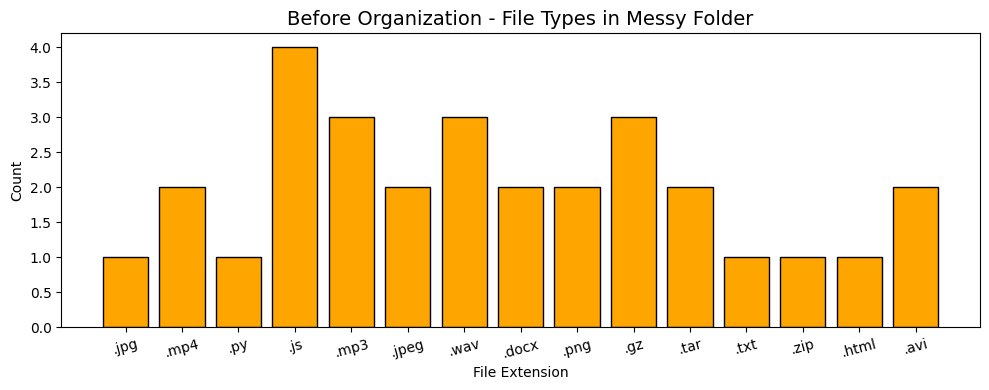

Total files before organization: 30



In [ ]:
def visualize_before(directory):
    files = os.listdir(directory)
    extensions = [os.path.splitext(f)[1] for f in files]
    counts = Counter(extensions)

    plt.figure(figsize=(10, 4))
    plt.bar(counts.keys(), counts.values(), color="orange", edgecolor="black")
    plt.title("Before Organization - File Types in Messy Folder", fontsize=14)
    plt.xlabel("File Extension")
    plt.ylabel("Count")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    print(f"Total files before organization: {len(files)}\n")

visualize_before(messy_dir)

In [ ]:
# Organized directory
organized_dir = "/content/organized_folder"
os.makedirs(organized_dir, exist_ok=True)

# Build extension → category map
ext_to_category = {}
for category, exts in file_types.items():
    for ext in exts:
        ext_to_category[ext] = category

# Organization log
org_log = []

def organize_files(src, dst):
    files = os.listdir(src)
    print("🗂️ Organizing files...\n")

    for file in files:
        ext = os.path.splitext(file)[1].lower()
        category = ext_to_category.get(ext, "others")

        # Create category folder
        category_path = os.path.join(dst, category)
        os.makedirs(category_path, exist_ok=True)

        # Move file
        src_path = os.path.join(src, file)
        dst_path = os.path.join(category_path, file)
        shutil.copy2(src_path, dst_path)

        log_entry = {
            "file": file,
            "category": category,
            "time": datetime.datetime.now().strftime("%H:%M:%S")
        }
        org_log.append(log_entry)
        print(f"  [{log_entry['time']}] {file} → {category}/")

    print(f"\n✅ {len(files)} files organized into {len(os.listdir(dst))} categories")

organize_files(messy_dir, organized_dir)

🗂️ Organizing files...

  [00:43:46] file_10.jpg → images/
  [00:43:46] file_1.mp4 → videos/
  [00:43:46] file_26.py → code/
  [00:43:46] file_19.mp4 → videos/
  [00:43:46] file_9.js → code/
  [00:43:46] file_18.mp3 → audio/
  [00:43:46] file_14.mp3 → audio/
  [00:43:46] file_2.jpeg → images/
  [00:43:46] file_5.js → code/
  [00:43:46] file_25.jpeg → images/
  [00:43:46] file_29.wav → audio/
  [00:43:46] file_3.docx → documents/
  [00:43:46] file_27.png → images/
  [00:43:46] file_7.gz → archives/
  [00:43:46] file_11.gz → archives/
  [00:43:46] file_30.wav → audio/
  [00:43:46] file_4.tar → archives/
  [00:43:46] file_13.txt → documents/
  [00:43:46] file_21.wav → audio/
  [00:43:46] file_23.zip → archives/
  [00:43:46] file_6.js → code/
  [00:43:46] file_20.html → code/
  [00:43:46] file_12.avi → videos/
  [00:43:46] file_24.js → code/
  [00:43:46] file_16.avi → videos/
  [00:43:46] file_22.mp3 → audio/
  [00:43:46] file_8.tar → archives/
  [00:43:46] file_15.docx → documents/
  [00:

In [ ]:
backup_dir = "/content/backup"
os.makedirs(backup_dir, exist_ok=True)

backup_log = []

def backup_files(src):
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_path = os.path.join(backup_dir, f"backup_{timestamp}")
    shutil.copytree(src, backup_path)

    # Log backup details
    total_files = sum(len(files) for _, _, files in os.walk(backup_path))
    size = sum(
        os.path.getsize(os.path.join(dp, f))
        for dp, _, files in os.walk(backup_path)
        for f in files
    )

    backup_log.append({
        "timestamp": timestamp,
        "path": backup_path,
        "total_files": total_files,
        "size_bytes": size
    })

    print(f"💾 Backup completed!")
    print(f"   Path       : {backup_path}")
    print(f"   Files      : {total_files}")
    print(f"   Total Size : {size} bytes")

backup_files(organized_dir)

💾 Backup completed!
   Path       : /content/backup/backup_20260522_004346
   Files      : 30
   Total Size : 978 bytes


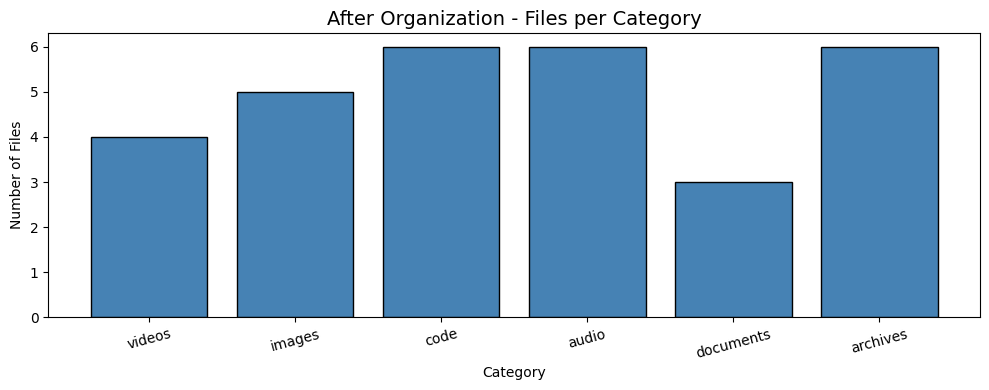

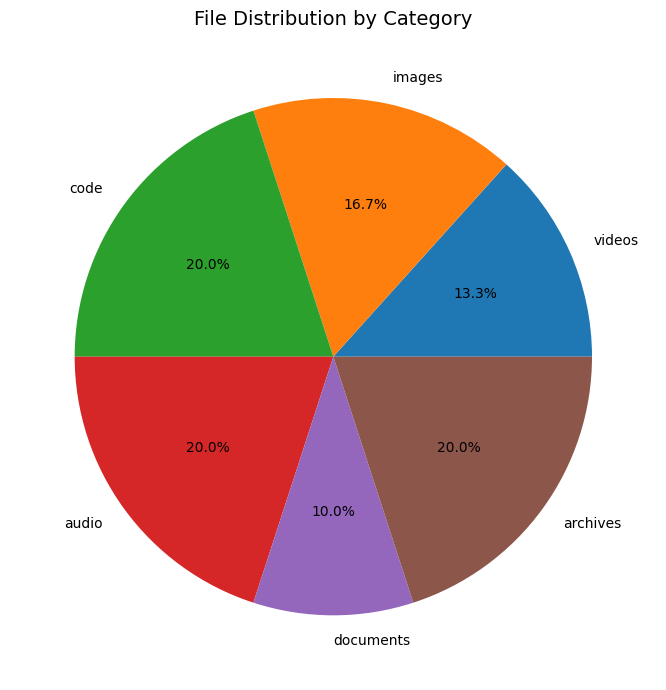

Total files after organization: 30


In [ ]:
def visualize_after(directory):
    categories = os.listdir(directory)
    file_counts = {}

    for cat in categories:
        cat_path = os.path.join(directory, cat)
        if os.path.isdir(cat_path):
            file_counts[cat] = len(os.listdir(cat_path))

    # Bar chart
    plt.figure(figsize=(10, 4))
    plt.bar(file_counts.keys(), file_counts.values(), color="steelblue", edgecolor="black")
    plt.title("After Organization - Files per Category", fontsize=14)
    plt.xlabel("Category")
    plt.ylabel("Number of Files")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Pie chart
    plt.figure(figsize=(7, 7))
    plt.pie(
        file_counts.values(),
        labels=file_counts.keys(),
        autopct="%1.1f%%",
        colors=plt.cm.tab10.colors
    )
    plt.title("File Distribution by Category", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"Total files after organization: {sum(file_counts.values())}")

visualize_after(organized_dir)

In [ ]:
print(f"{'File':<25} {'Category':<15} {'Time':<10}")
print("-" * 55)
for entry in org_log:
    print(f"{entry['file']:<25} {entry['category']:<15} {entry['time']:<10}")

File                      Category        Time      
-------------------------------------------------------
file_10.jpg               images          00:43:46  
file_1.mp4                videos          00:43:46  
file_26.py                code            00:43:46  
file_19.mp4               videos          00:43:46  
file_9.js                 code            00:43:46  
file_18.mp3               audio           00:43:46  
file_14.mp3               audio           00:43:46  
file_2.jpeg               images          00:43:46  
file_5.js                 code            00:43:46  
file_25.jpeg              images          00:43:46  
file_29.wav               audio           00:43:46  
file_3.docx               documents       00:43:46  
file_27.png               images          00:43:46  
file_7.gz                 archives        00:43:46  
file_11.gz                archives        00:43:46  
file_30.wav               audio           00:43:46  
file_4.tar                archives        0

In [ ]:
def cleanup_old_files(directory, days_old=0):
    print(f"\n🧹 Running cleanup on: {directory}")
    removed = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            removed.append(file)
            os.remove(filepath)

    print(f"  Removed {len(removed)} old files")
    for f in removed:
        print(f"  🗑️ Deleted: {f}")

cleanup_old_files(messy_dir)


🧹 Running cleanup on: /content/messy_folder
  Removed 30 old files
  🗑️ Deleted: file_10.jpg
  🗑️ Deleted: file_1.mp4
  🗑️ Deleted: file_26.py
  🗑️ Deleted: file_19.mp4
  🗑️ Deleted: file_9.js
  🗑️ Deleted: file_18.mp3
  🗑️ Deleted: file_14.mp3
  🗑️ Deleted: file_2.jpeg
  🗑️ Deleted: file_5.js
  🗑️ Deleted: file_25.jpeg
  🗑️ Deleted: file_29.wav
  🗑️ Deleted: file_3.docx
  🗑️ Deleted: file_27.png
  🗑️ Deleted: file_7.gz
  🗑️ Deleted: file_11.gz
  🗑️ Deleted: file_30.wav
  🗑️ Deleted: file_4.tar
  🗑️ Deleted: file_13.txt
  🗑️ Deleted: file_21.wav
  🗑️ Deleted: file_23.zip
  🗑️ Deleted: file_6.js
  🗑️ Deleted: file_20.html
  🗑️ Deleted: file_12.avi
  🗑️ Deleted: file_24.js
  🗑️ Deleted: file_16.avi
  🗑️ Deleted: file_22.mp3
  🗑️ Deleted: file_8.tar
  🗑️ Deleted: file_15.docx
  🗑️ Deleted: file_17.png
  🗑️ Deleted: file_28.gz
